# Spatiotemporal Analysis of Air Pollution Exposure Disparities by Race/Ethnicity and Historical Redlining in the Contiguous United States, 2000–2010

**Authors:** Mohsen Nikfarjam, Ehsan Nikfarjam

**Date:** January 11, 2026

---

### **Abstract**
**Background:** Inequitable exposure to ambient air pollution is a persistent public health concern in the United States. Discriminatory housing policies of the 20th century, specifically the Home Owners' Loan Corporation (HOLC) "redlining" maps, are posited as structural antecedents to modern environmental disparities (Lane et al., 2022; Nelson et al., 2023).

**Methods:** We integrated block-level data from the 2000 and 2010 U.S. Censuses with modeled concentrations of nitrogen dioxide ($NO_2$) and fine particulate matter ($PM_{2.5}$). Using a memory-optimized chunked CPU workflow (dtype downcasting, 1,000,000-row processing chunks, parallel rendering via datashader), we calculated population-weighted mean (PWM) exposures, disparity ratios, and intersectional statistics stratified by race/ethnicity and historical HOLC grade (Kim et al., 2020; Manson et al., 2024).

**Results:** While national population-weighted air quality improved between 2000 and 2010 ($NO_2$: 14.63 to 8.93 ppb, -39%; $PM_{2.5}$: 13.27 to 9.44 $\mu g/m^3$, -29%), relative exposure disparities persisted. In 2010, population-weighted $NO_2$ averaged 16.8 ppb in historically "Hazardous" (Grade D) areas against 10.7 ppb in "Best" (Grade A) areas, a difference of 57%. Racial/ethnic minorities experienced higher burdens within every HOLC grade, suggesting that historical redlining and contemporary demographic sorting act as compounding factors (Clark et al., 2017; Lane et al., 2022).

**Conclusion:** The spatial structure of historical inequity remains highly correlated with environmental injustice. Targeted policy interventions addressing these specific intersectional domains are required to mitigate attributable health burdens (Wang et al., 2022b).

### **Plain Language Summary**
This study examines how air pollution affects different racial and ethnic groups across the United States and how these patterns relate to historical housing discrimination ("redlining"). Analyzing data from 2000 to 2010, we found that although air quality improved nationally, communities of color continued to breathe significantly more polluted air than white communities. Areas historically marked as "hazardous" for mortgage lending in the 1930s still exhibit the highest pollution levels today. These findings highlight that historical policies continue to shape modern environmental health risks.

---

## Table of Contents

1. [Analysis Environment and Data Summary](#1-analysis-environment-and-data-summary)
2. [Methodology](#2-methodology)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Results](#4-results)
    - 4.2 [Spatial Heterogeneity of Air Quality Improvements](#42-spatial-heterogeneity-of-air-quality-improvements)
    - 4.3 [Intersectional Analysis: Historical Redlining](#43-intersectional-analysis-historical-redlining)
5. [Discussion](#5-discussion)
    - 5.1 [Limitations](#51-limitations)
6. [Conclusion](#6-conclusion)
7. [Future Research Directions](#7-future-research-directions)
8. [Interactive Digital Assets](#8-interactive-digital-assets)
9. [Acknowledgments and Data Sources](#9-acknowledgments-and-data-sources)
10. [References](#10-references)


---

<a id="1-analysis-environment-and-data-summary" name="1-analysis-environment-and-data-summary"></a>

## **1. Analysis Environment and Data Summary**

The cell below resolves the analysis asset directory and summarizes the three
input datasets. Concentration surfaces, census demographics, and HOLC polygons
are described in Section 2.


In [ ]:
# @title 1. Analysis Environment & Data Summary
# This notebook presents the results of a large-scale spatiotemporal analysis.
# The computational pipeline is CPU-based and memory-optimized: dtype downcasting,
# 1,000,000-row processing chunks, and datashader rendering with ProcessPool
# parallelism, which is what makes ~3.08M block polygons tractable without a GPU.
# That pipeline has already been executed; assets are loaded from the report repository.

import pandas as pd
import os
from pathlib import Path
from IPython.display import display, HTML, Image, Markdown

# --- Configuration ---
# Mount Google Drive to access the pre-computed analysis assets
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive Mounted")
except ImportError:
    print("⚠️ Google Colab environment not detected. Skipping Drive mount.")

# --- Portable asset resolution -------------------------------------------
# The figures are 1200-dpi print assets held outside the repository. Resolve
# the first candidate that exists rather than hardcoding one machine's path,
# so the notebook runs unchanged on Colab, locally, or from a clone.
ASSET_CANDIDATES = [
    Path('/content/drive/MyDrive/Colab_Data/Air_Quality_Project'),
    Path(r"D:\Drive D\ML DS\Completed Projects\Spatiotemporal Analysis AQM EJ\Air-Quality-Exposure\output\FINAL_REPORT_ASSETS"),
    Path.cwd() / 'FINAL_REPORT_ASSETS',
    Path.cwd() / 'assets',
]

def resolve_assets_dir():
    """Return the first candidate asset directory that exists."""
    for candidate in ASSET_CANDIDATES:
        if candidate.exists():
            return candidate
    return ASSET_CANDIDATES[0]

ASSETS_DIR = resolve_assets_dir()

def show_figure(filepath, width=800, max_px=1200):
    """Display a figure at web resolution.

    The source assets are rendered at 1200 dpi (8,000-12,000 px wide) for print.
    Embedding them at native resolution produces a notebook too large to render
    on GitHub, which is why the outputs were previously stripped. Downsampling
    to max_px on the long edge preserves all detail visible at the displayed
    width while keeping the stored output small.
    """
    filepath = Path(filepath)
    try:
        from PIL import Image as _PILImage
        import io as _io
        _PILImage.MAX_IMAGE_PIXELS = None
        with _PILImage.open(filepath) as _im:
            if _im.mode == 'RGBA':
                _bg = _PILImage.new('RGB', _im.size, 'white')
                _bg.paste(_im, mask=_im.split()[3])
                _im = _bg
            else:
                _im = _im.convert('RGB')
            if _im.width > max_px:
                _im = _im.resize((max_px, round(_im.height * max_px / _im.width)),
                                 _PILImage.LANCZOS)
            _im = _im.quantize(colors=256, dither=_PILImage.FLOYDSTEINBERG)
            _buf = _io.BytesIO()
            _im.save(_buf, 'PNG', optimize=True)
        display(Image(data=_buf.getvalue(), width=width))
    except ImportError:
        # Pillow unavailable: fall back to the full-resolution asset.
        display(Image(filename=str(filepath), width=width))

if not ASSETS_DIR.exists():
    print(f"⚠️ Assets directory not found. Tried: {[str(p) for p in ASSET_CANDIDATES]}")
    print("   Figures below are the outputs stored in this notebook, not regenerated.")
else:
    print(f"✅ Analysis Assets Loaded from: {ASSETS_DIR}")

# --- Data File Summaries ---

# 1. Pollution Data Files Summary (From Table 3)
pollution_data = {
    'Dataset File': ['NO2_2000.parquet', 'PM25_2000.parquet', 'NO2_2010.parquet', 'PM25_2010.parquet'],
    'Metric (Unit)': ['NO₂ (ppb)', 'PM₂.₅ (µg/m³)', 'NO₂ (ppb)', 'PM₂.₅ (µg/m³)'],
    'Year': [2000, 2000, 2010, 2010],
    'Mean': [10.70, 12.25, 6.81, 9.17],
    'Std Dev': [6.16, 3.36, 4.17, 2.37],
    'Max': [47.28, 26.35, 35.62, 16.59],
    'Records (N)': ['3,080,166', '3,080,166', '3,080,166', '3,080,166']
}

# 2. Census Data Files Summary (From Tables 1 & 2)
census_data = {
    'Dataset File': ['Census_2000.parquet', 'Census_2010.parquet'],
    'Total Population': ['139,665,947', '156,820,030'],
    'Populated Blocks': ['2,404,319', '3,058,300'],
    '% White': ['68.1%', '63.6%'],
    '% Black': ['12.7%', '12.7%'],
    '% Hispanic': ['13.0%', '16.4%'],
    '% Asian': ['3.7%', '4.5%']
}

# 3. Historical Redlining (HOLC) Data Summary (From Table 1)
holc_data = {
    'Dataset File': ['HOLC_Polygons.geojson'],
    'Total Polygons': [10154],
    'Grade A (Best)': [1094],
    'Grade B (Still Desirable)': [2481],
    'Grade C (Declining)': [3559],
    'Grade D (Hazardous)': [2188]
}

# Create DataFrames
df_pollution = pd.DataFrame(pollution_data)
df_census = pd.DataFrame(census_data)
df_holc = pd.DataFrame(holc_data)

# Styling Function
def style_table(df, caption):
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', '#333'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px'), ('border', '1px solid #ddd')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px'), ('border', '1px solid #ddd')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '1.1em'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ]).set_caption(caption).hide(axis='index')

# Display Summaries
display(Markdown("### **Executive Data Summary by Input Source**"))
display(style_table(df_pollution, "Table 1: Pollution Data Summary (unweighted block-level aggregates; these are NOT the population-weighted means reported in the Abstract and Results)"))
display(Markdown("---"))
display(style_table(df_census, "Table 2: Census Data Summary (Demographic Composition)"))
display(Markdown("---"))
display(style_table(df_holc, "Table 3: Historical Redlining (HOLC) Data Summary"))

Mounted at /content/drive
✅ Google Drive Mounted
✅ Analysis Assets Loaded from: /content/drive/MyDrive/Colab_Data/Air_Quality_Project


### **Executive Data Summary by Input Source**

Dataset File,Metric (Unit),Year,Mean,Std Dev,Max,Records (N)
NO2_2000.parquet,NO₂ (ppb),2000,10.700000,6.160000,47.280000,"3,080,166"
PM25_2000.parquet,PM₂.₅ (µg/m³),2000,12.250000,3.360000,26.350000,"3,080,166"
NO2_2010.parquet,NO₂ (ppb),2010,6.810000,4.170000,35.620000,"3,080,166"
PM25_2010.parquet,PM₂.₅ (µg/m³),2010,9.170000,2.370000,16.590000,"3,080,166"


---

Dataset File,Total Population,Populated Blocks,% White,% Black,% Hispanic,% Asian
Census_2000.parquet,"139,665,947","2,404,319",68.1%,12.7%,13.0%,3.7%
Census_2010.parquet,"156,820,030","3,058,300",63.6%,12.7%,16.4%,4.5%


---

Dataset File,Total Polygons,Grade A (Best),Grade B (Still Desirable),Grade C (Declining),Grade D (Hazardous)
HOLC_Polygons.geojson,10154,1094,2481,3559,2188


<a id="2-methodology" name="2-methodology"></a>

## **2. Methodology**

### **2.1 Data Integration**
Our analytical dataset integrates three primary domains:
1.  **Demographics:** Block-level population counts by race/ethnicity from the 2000 and 2010 Decennial Censuses (Manson et al., 2024).
2.  **Air Pollution:** Annual average concentrations for $NO_2$ and $PM_{2.5}$ derived from Center for Air, Climate, and Energy Solutions (CACES) empirical geographic regression models (Kim et al., 2020; Wang, 2022).
3.  **Historical Housing:** Digitized HOLC security map polygons from the *Mapping Inequality* project (Nelson et al., 2023).

### **2.2 Exposure Metrics**
To account for the uneven spatial distribution of populations, we utilized the Population-Weighted Mean (PWM) exposure metric (Marshall, 2008). For a specific demographic group $i$, the PWM is calculated as:

$$PWM_i = \frac{\sum_{j=1}^{n} (P_{ij} \times C_j)}{\sum_{j=1}^{n} P_{ij}}$$

Where:
* $P_{ij}$ is the population of group $i$ in census block $j$.
* $C_j$ is the pollutant concentration in census block $j$.
* $n$ is the total number of census blocks.

Relative disparity is quantified using the Disparity Ratio:

$$\text{Disparity Ratio} = \frac{PWM_{\text{Minority Group}}}{PWM_{\text{Reference Group (White)}}}$$

<a id="3-exploratory-data-analysis" name="3-exploratory-data-analysis"></a>

## **3. Exploratory Data Analysis**

Before proceeding to exposure modeling, we conducted a rigorous diagnostic assessment of the underlying datasets to verify data integrity, temporal stability, and key distributional properties. This exploratory phase evaluates the two primary input domains: sociodemographic composition and air pollution concentrations.

### **3.1 Univariate Distributions**
The unweighted frequency distributions for key variables reveal distinct underlying structures.
* **Population Counts:** Census block population counts are heavily right-skewed, consistent with the log-normal distribution typical of human settlement patterns.
* **Pollutant Concentrations:** $NO_2$ concentrations exhibit a right-skewed distribution, consistent with the influence of localized high-emission sources. Conversely, $PM_{2.5}$ distributions are approximately normal, consistent with a larger regional background contribution. Note that these data resolve spatial scale, not emission sector: attributing the near-source $NO_2$ component to traffic specifically is a proxy interpretation, not a measurement, and would require validation against a source-specific emissions inventory.

The temporal stability of these distributions between 2000 and 2010 supports the use of these datasets for longitudinal comparison.

### **3.2 Temporal Correlation and Stability**
We quantified the temporal persistence of spatial patterns between 2000 and 2010 to assess the stability of the exposure landscape.
* **Pollution Persistence:** A high degree of temporal persistence was observed for both pollutants. The Pearson correlation coefficient ($r$) for block-level concentrations between 2000 and 2010 was $r=0.946$ for $NO_2$ and $r=0.833$ for $PM_{2.5}$. This statistic pairs each block with itself across two time points and therefore measures temporal stability; it is not a measure of spatial autocorrelation, which would require a spatial weights matrix (e.g., Moran's I). This indicates that the relative spatial ranking of polluted areas remained highly stable over the decade, even as absolute levels declined.
* **Demographic Inertia:** Racial and ethnic composition also exhibited strong temporal stability at the block level ($r \approx 0.7 - 0.8$), confirming that residential segregation patterns are durable structural features.

### **3.3 Inter-Pollutant Relationship**
The relationship between $NO_2$ and $PM_{2.5}$ provides insight into emission source dynamics. We observed a moderate positive correlation ($r \approx 0.4 - 0.5$) between the two pollutants. This imperfect correlation reflects their distinct physical behaviors: $NO_2$ decays rapidly near sources, while $PM_{2.5}$ has a longer atmospheric lifetime and is subject to regional transport.

### **3.4 Density-Disparity Relationship**
To investigate potential confounding by urban density, we analyzed the relationship between population density, racial composition, and pollution levels. As shown in the hexbin plots below, at any given level of population density, census blocks with a higher proportion of racial/ethnic minorities (indicated by color gradient) consistently exhibit higher average pollution concentrations. This finding indicates that exposure disparities are not explained by urbanization alone and remain associated with sociodemographic composition after conditioning on density. These are cross-sectional descriptive associations and do not establish a causal mechanism.

--- Data Distributions and Temporal Correlations ---


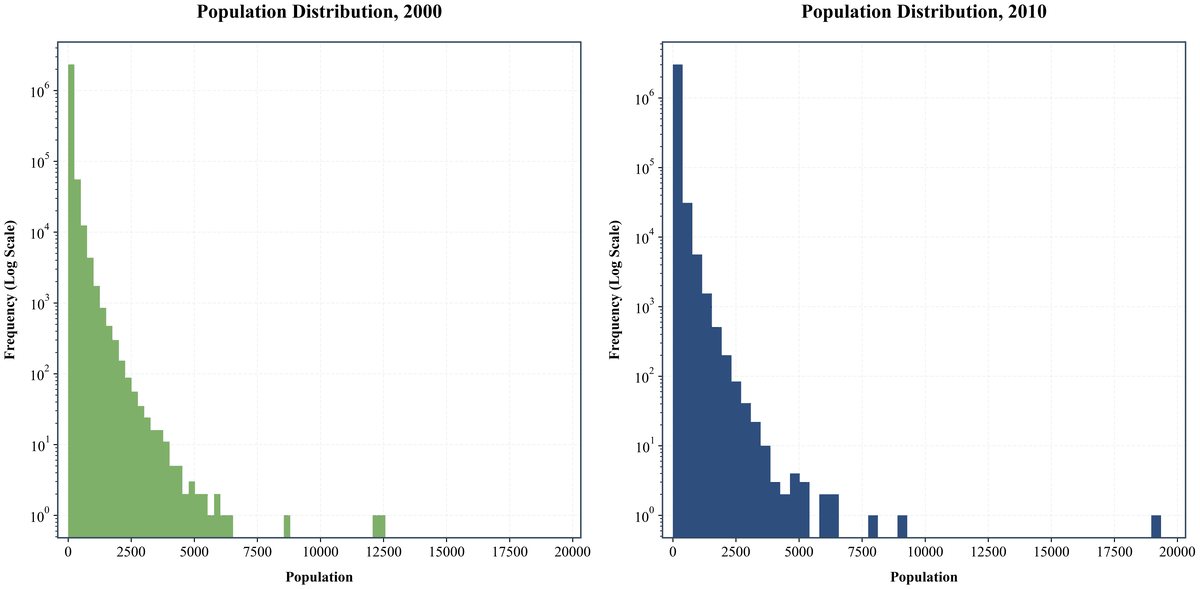

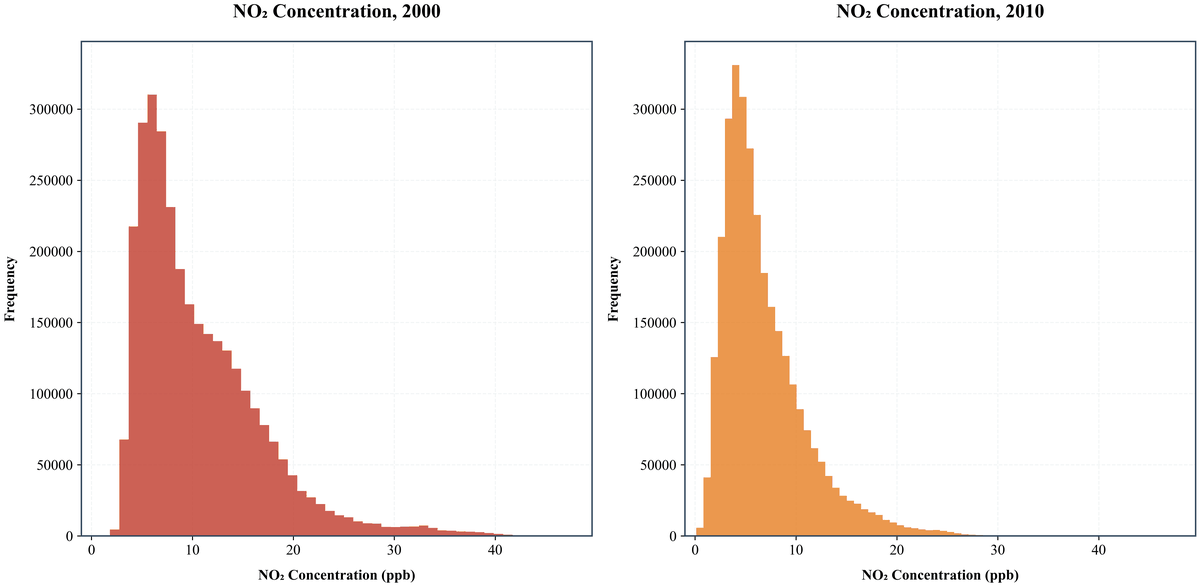

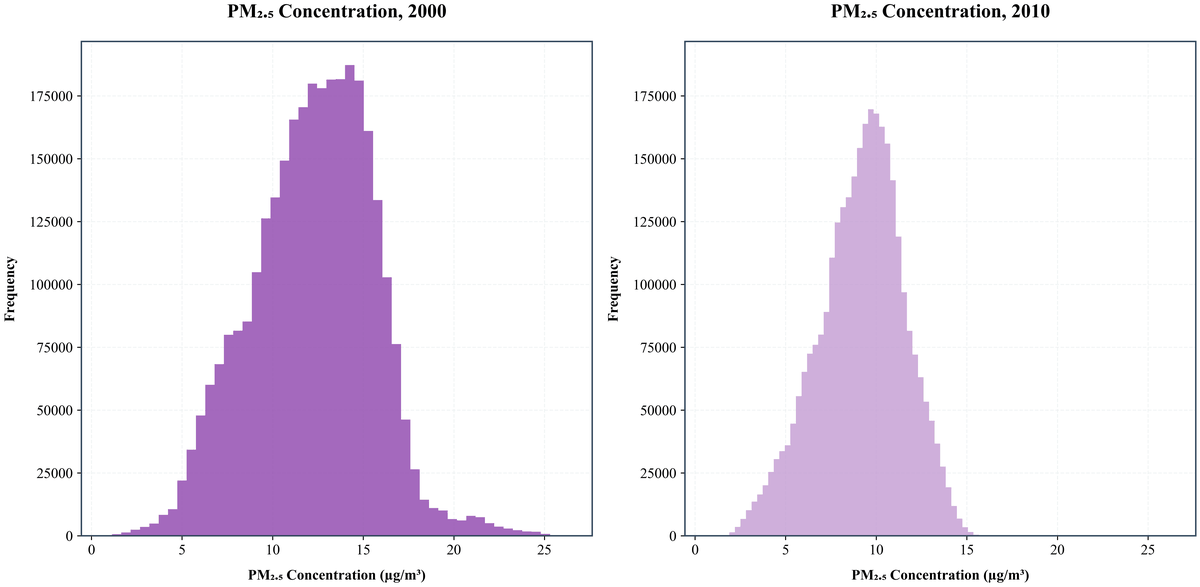

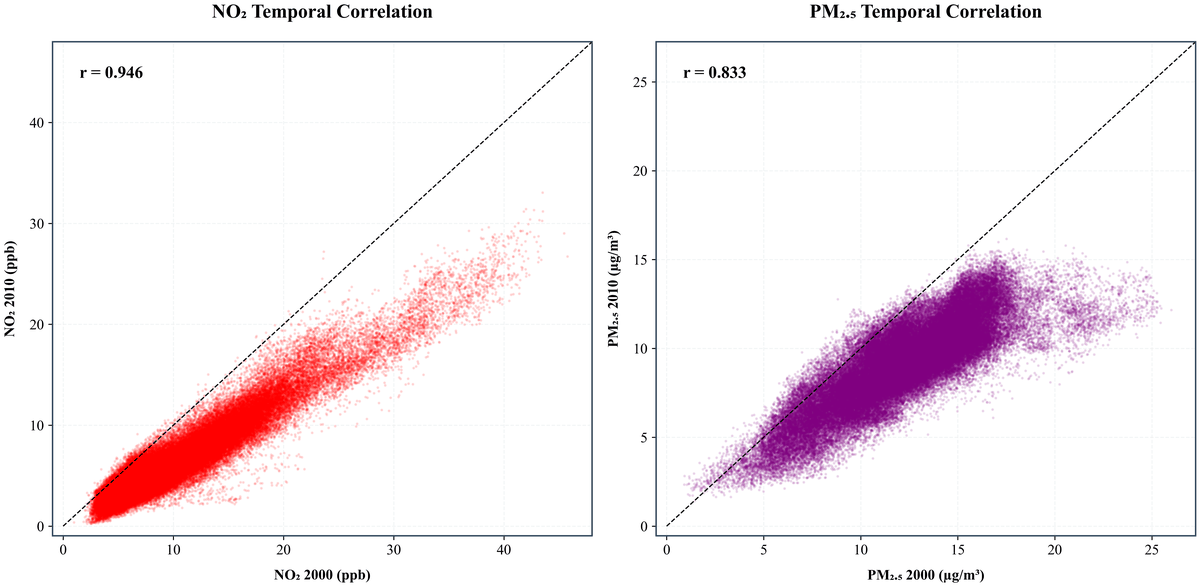

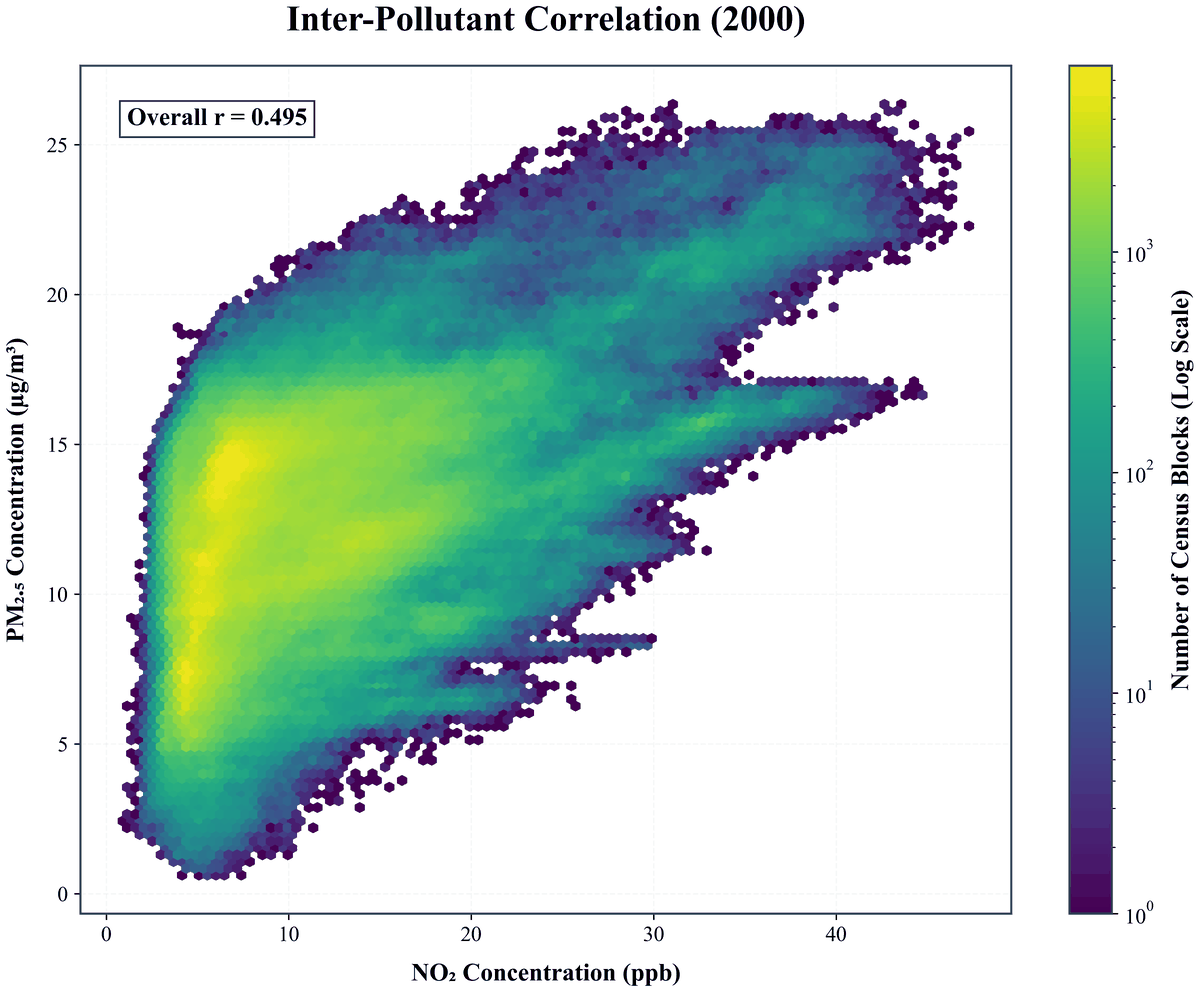

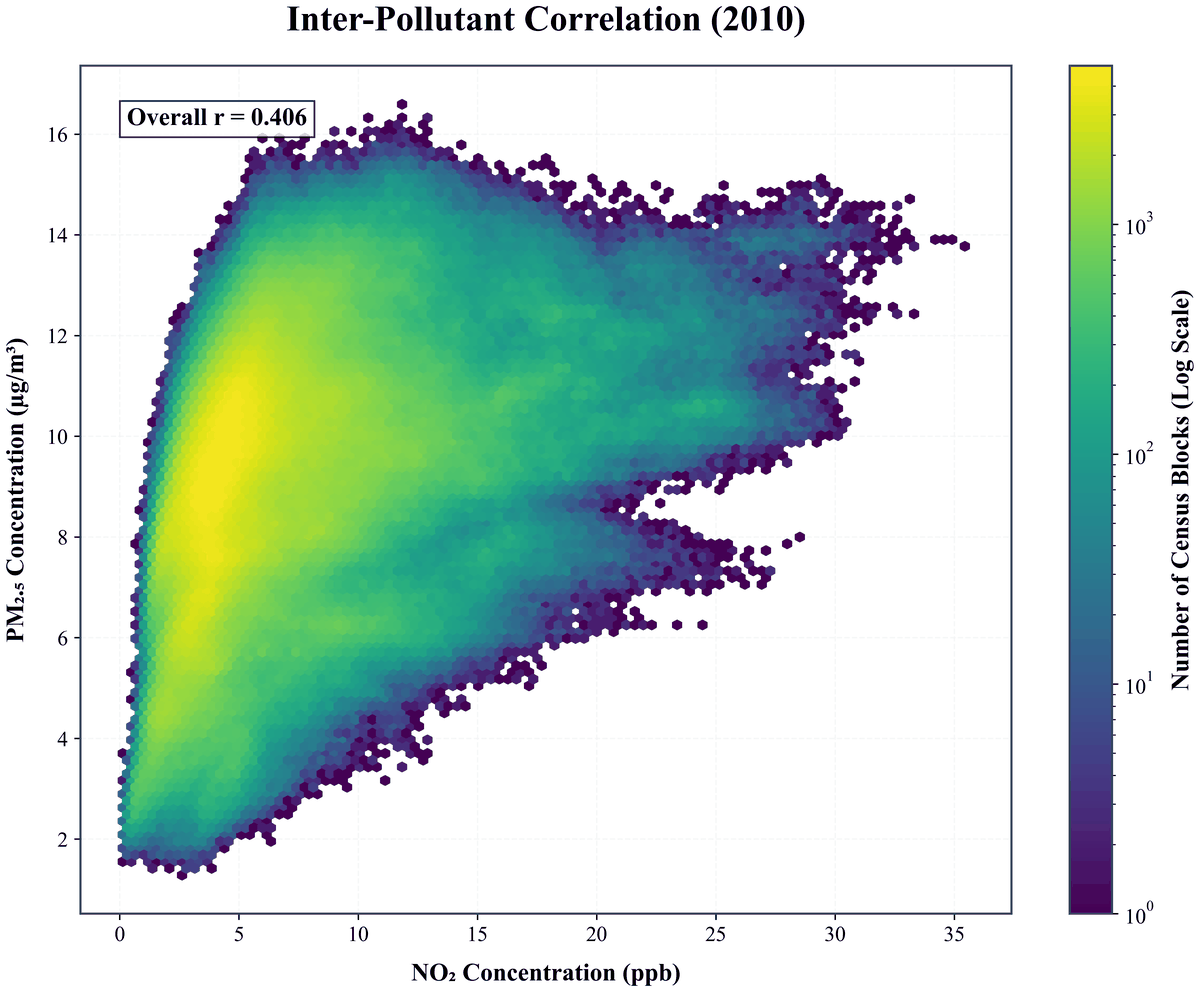

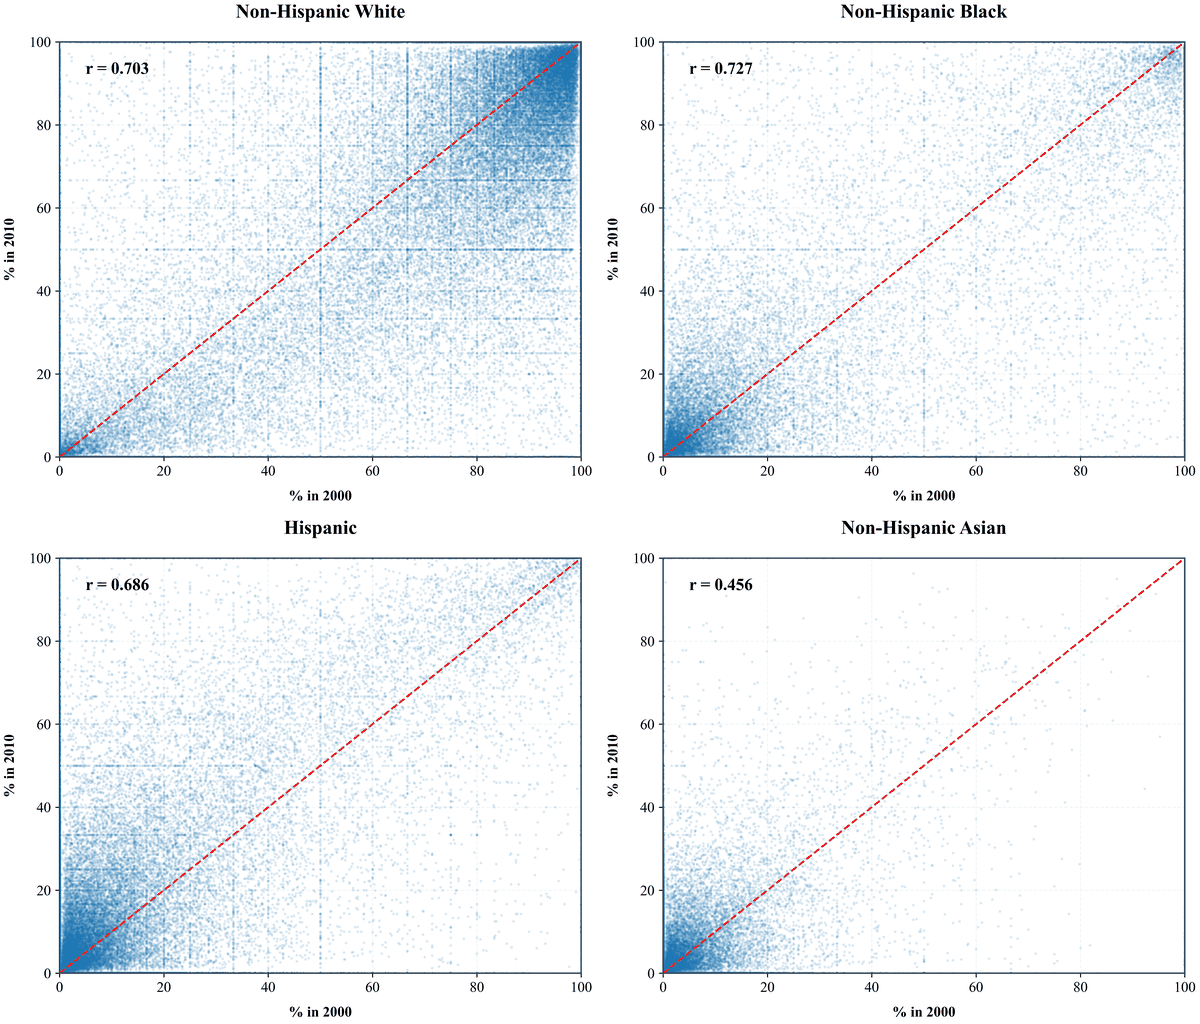


--- Density-Disparity Analysis (Population Density vs. Pollution vs. Demographics) ---



NO2 Density Disparity (2000)


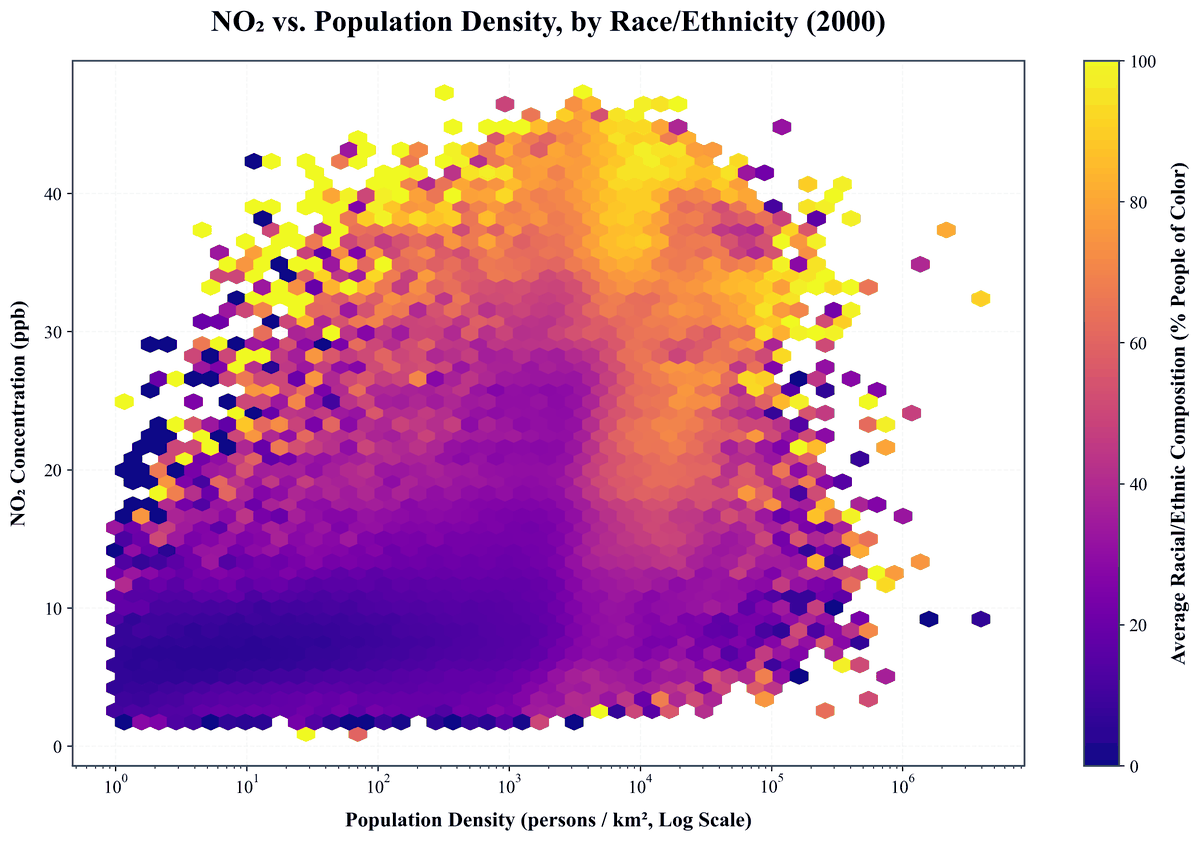


NO2 Density Disparity (2010)


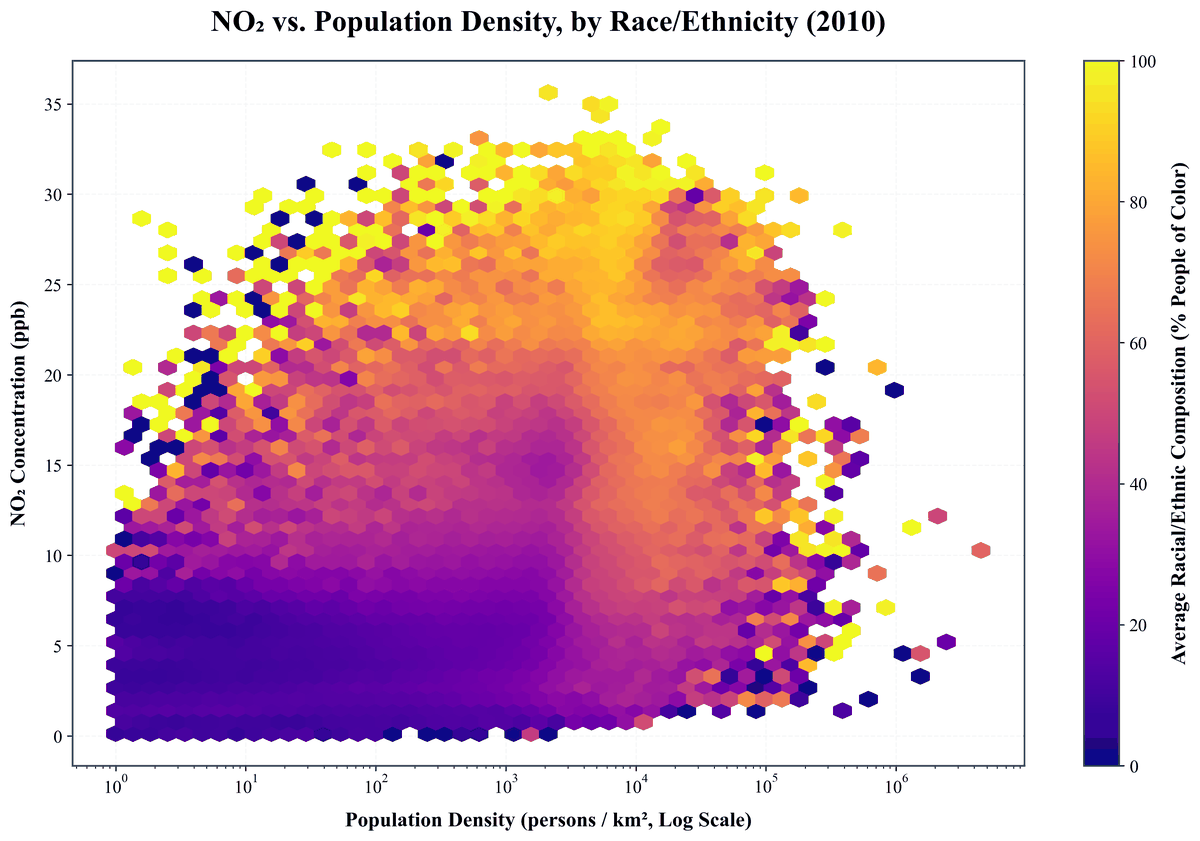


PM25 Density Disparity (2000)


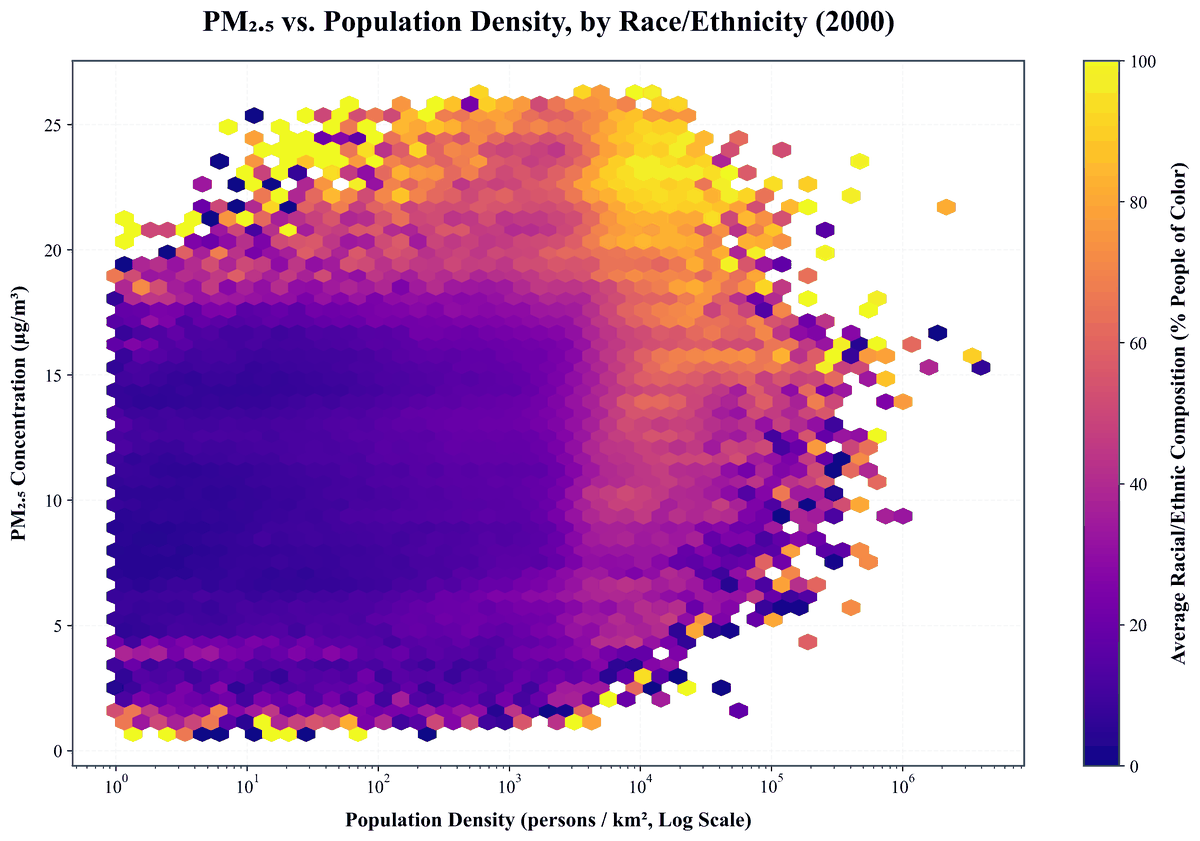


PM25 Density Disparity (2010)


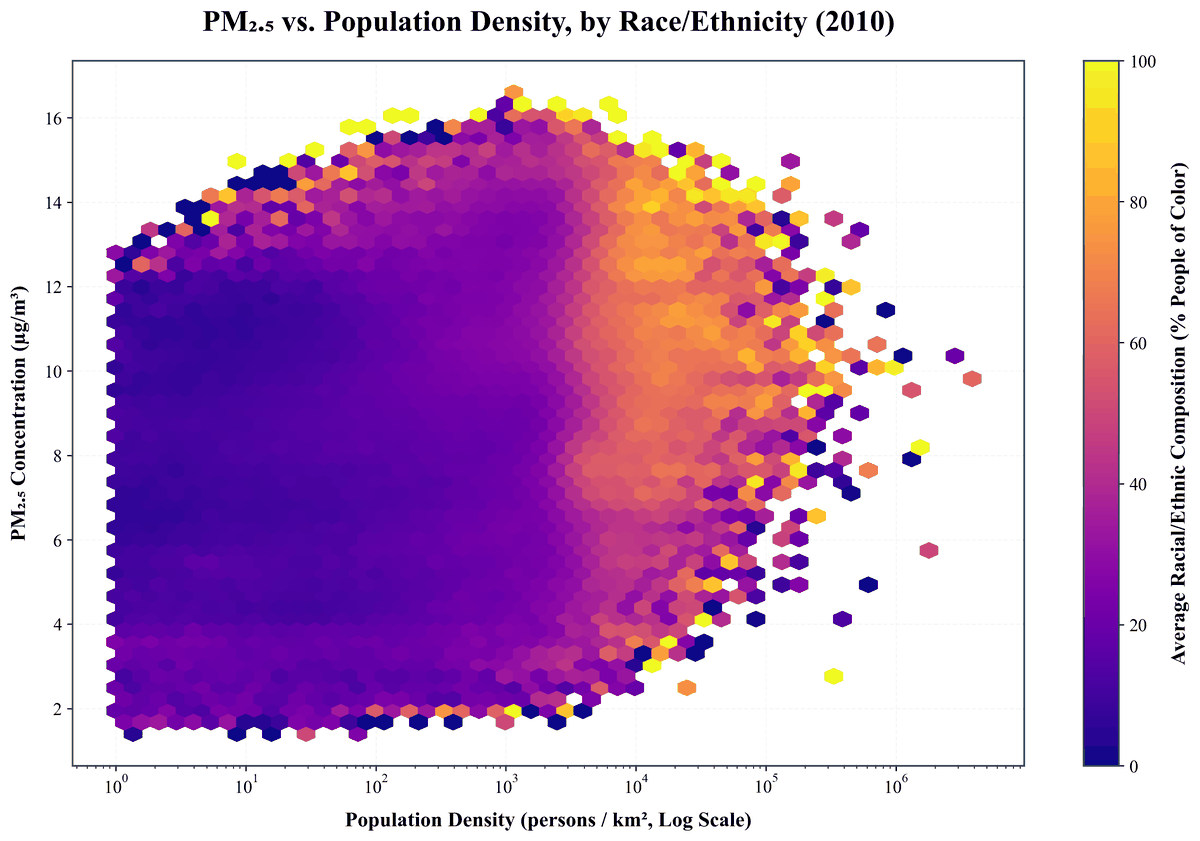

In [ ]:
# @title Figure 1: Exploratory Data Analysis Diagnostics
# Displaying key diagnostic plots for data validation and initial pattern recognition.

import os
from IPython.display import Image, display
from pathlib import Path

# Use the ASSETS_DIR resolved in the setup cell; re-resolve if run standalone.
if 'ASSETS_DIR' not in locals():
    ASSETS_DIR = resolve_assets_dir()

eda_plots = [
    'dist_population_counts.png',
    'dist_no2_concentrations.png',
    'dist_pm25_concentrations.png',
    'corr_pollutant_temporal.png',
    'pollutant_intercorrelation_2000.png',
    'pollutant_intercorrelation_2010.png',
    'demographic_correlation_plot.png'
]

# Display Distribution and Correlation Plots
print("--- Data Distributions and Temporal Correlations ---")
for plot in eda_plots:
    filepath = ASSETS_DIR / plot
    if filepath.exists():
        show_figure(filepath, width=800)
    else:
        print(f"Note: {plot} not found in assets directory.")

# Display Density-Disparity Plots (Hexbins)
print("\n--- Density-Disparity Analysis (Population Density vs. Pollution vs. Demographics) ---")
density_plots = [
    'density_disparity_NO2_2000.png',
    'density_disparity_NO2_2010.png',
    'density_disparity_PM25_2000.png',
    'density_disparity_PM25_2010.png'
]

for plot in density_plots:
    filepath = ASSETS_DIR / plot
    if filepath.exists():
        # Format a nice title based on the filename
        parts = plot.split('_')
        if len(parts) >= 4:
            pollutant = parts[2]
            year = parts[3].replace('.png', '')
            print(f"\n{pollutant} Density Disparity ({year})")
        else:
            print(f"\n{plot}")

        show_figure(filepath, width=900)
    else:
        print(f"Note: {plot} not found in assets directory.")

<a id="4-results" name="4-results"></a>

## **4. Results**

### **4.1 National Exposure Trends and Disparities**
Between 2000 and 2010, the national population-weighted mean concentration for $NO_2$ declined by 39% (14.63 ppb to 8.93 ppb), and $PM_{2.5}$ declined by 29% ($13.27 \mu g/m^3$ to $9.44 \mu g/m^3$). These trends are consistent with previous national assessments of air quality improvement (Liu et al., 2021).

However, distributional inequities remained statistically significant. As visualized below, the exposure distributions for Non-Hispanic Black, Hispanic, and Asian populations are consistently right-skewed (shifted toward higher pollution) compared to the Non-Hispanic White population.

Displaying pre-generated exposure distribution plots...



--- PM25 Exposure Distribution (2000) ---


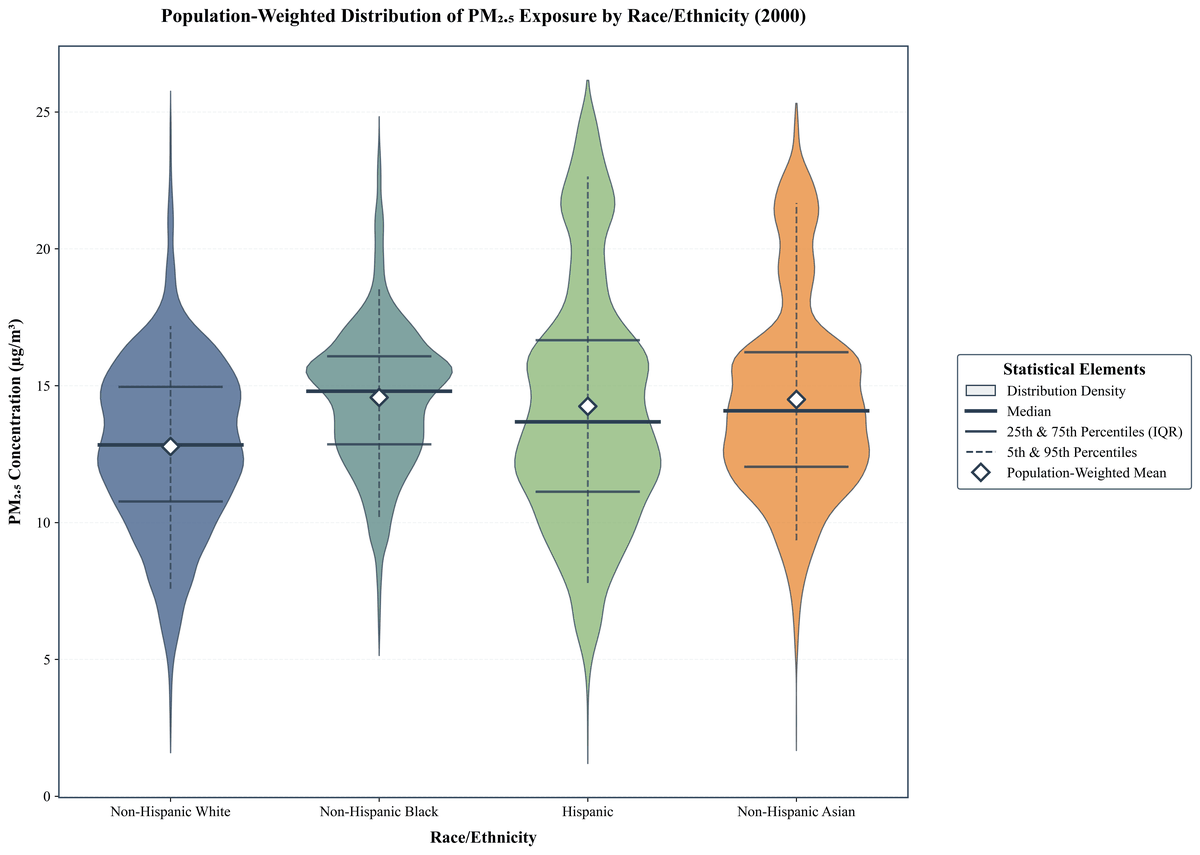


--- PM25 Exposure Distribution (2010) ---


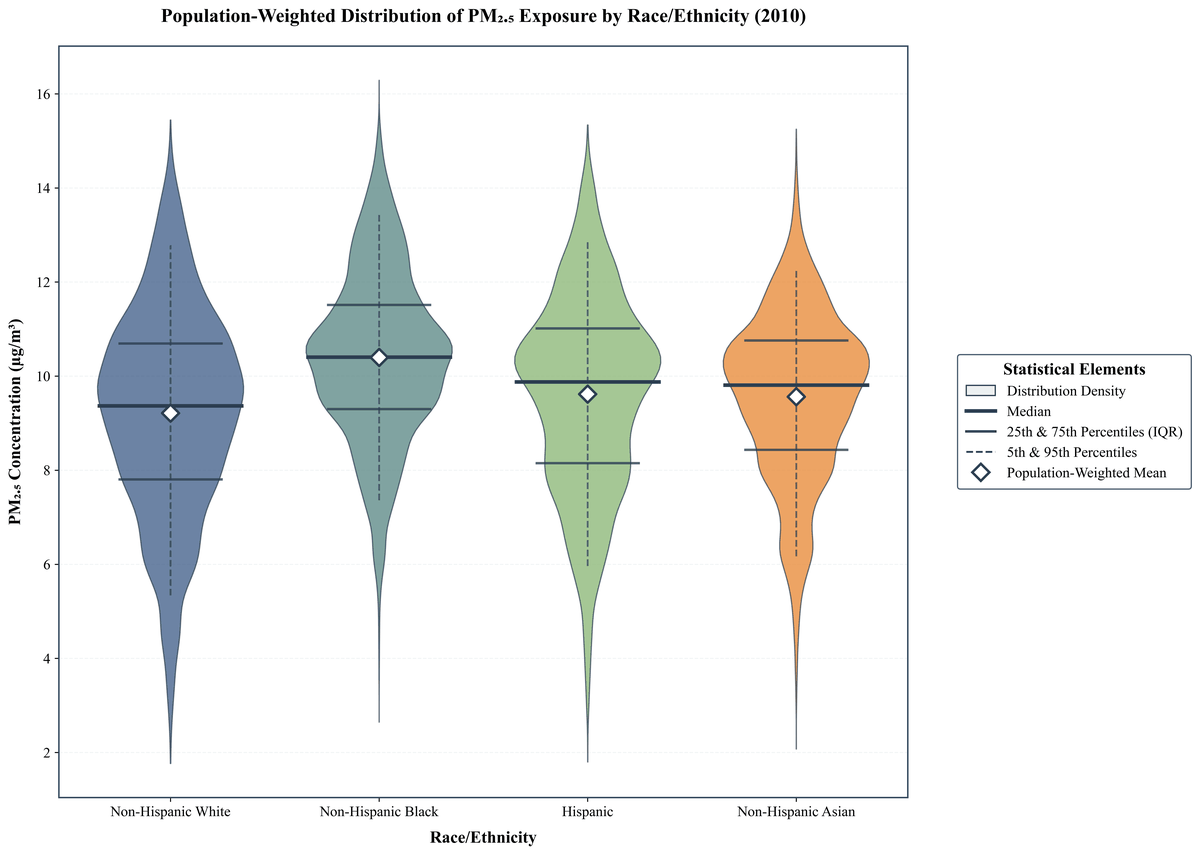


--- NO2 Exposure Distribution (2000) ---


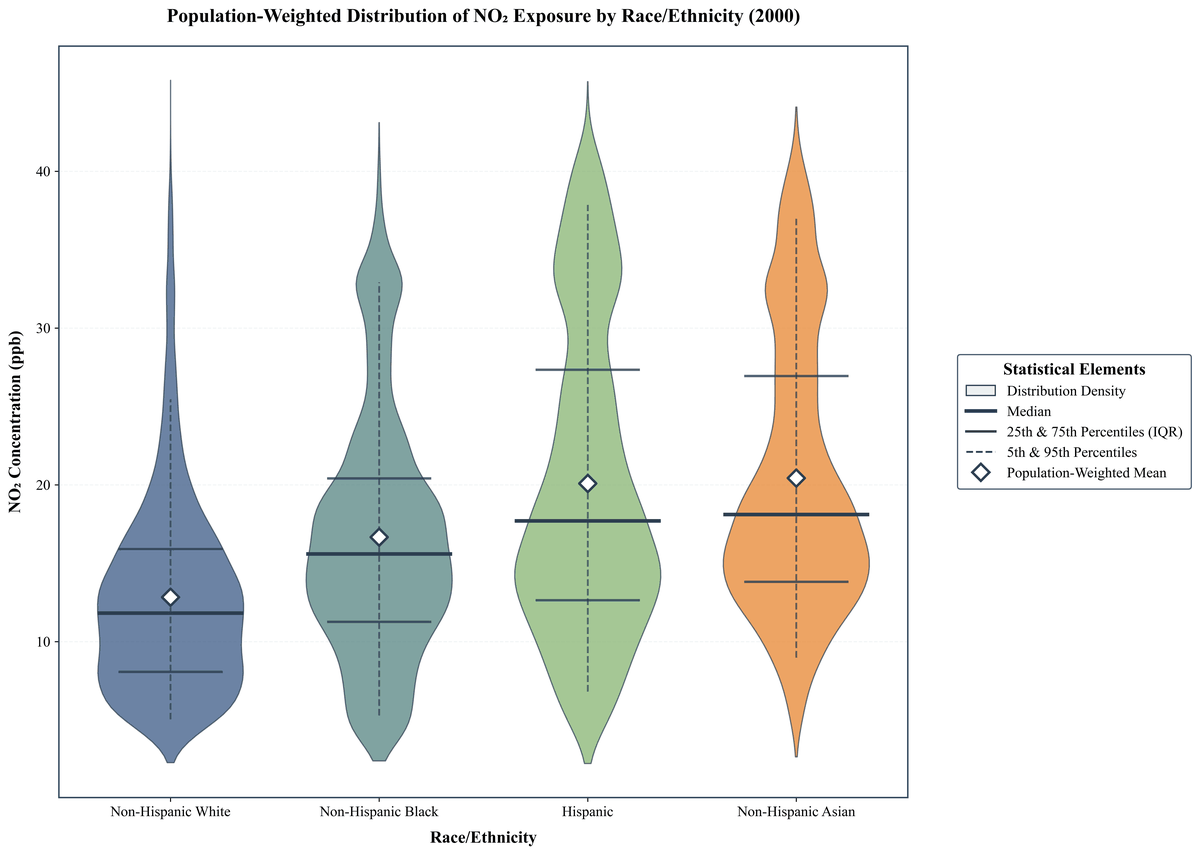


--- NO2 Exposure Distribution (2010) ---


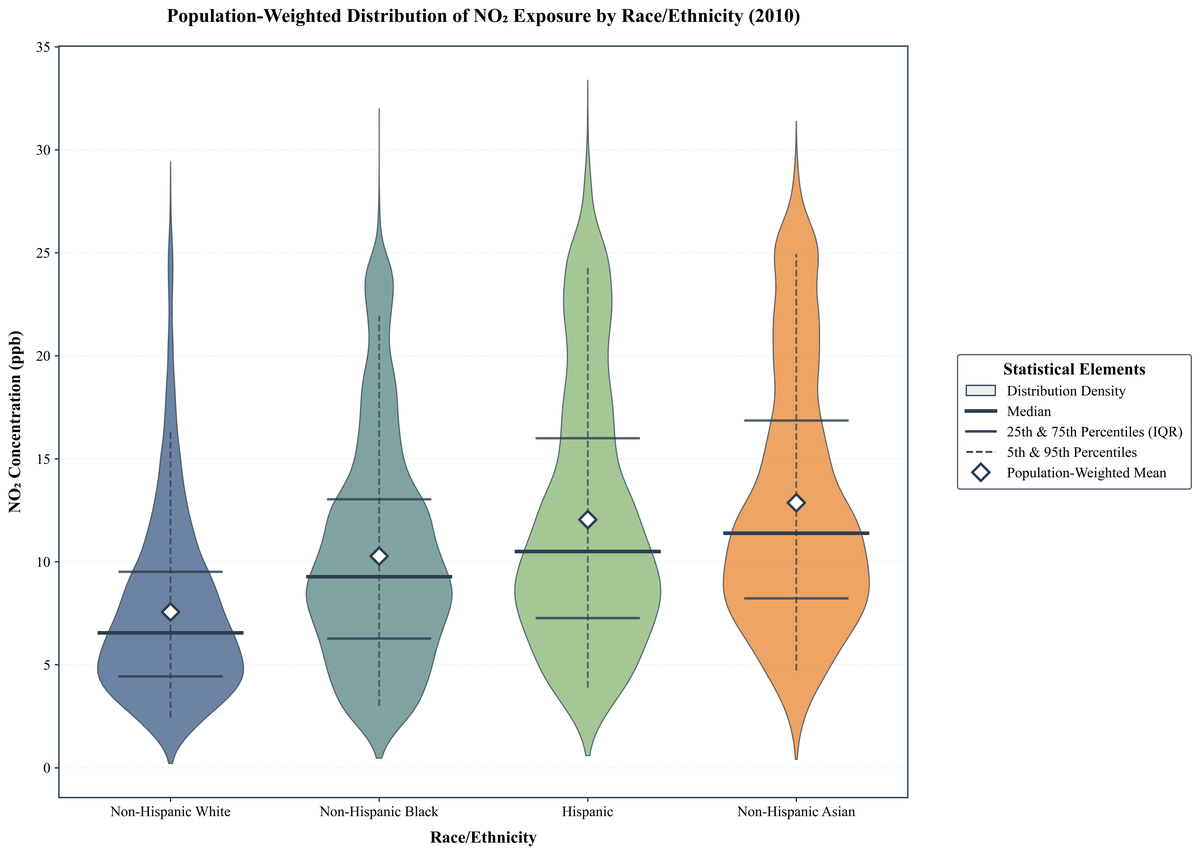

In [ ]:
# @title Figure 2: Population-Weighted Exposure Distributions (Violin Plots)
from IPython.display import Image, display
from pathlib import Path

# Parameters
pollutants = ['PM25', 'NO2']
years = [2000, 2010]

if 'ASSETS_DIR' not in locals():
    ASSETS_DIR = resolve_assets_dir()

print("Displaying pre-generated exposure distribution plots...")

for pollutant in pollutants:
    for year in years:
        filename = f"enhanced_violin_{pollutant}_{year}.png"
        filepath = ASSETS_DIR / filename
        if filepath.exists():
            print(f"\n--- {pollutant} Exposure Distribution ({year}) ---")
            show_figure(filepath, width=800)
        else:
            print(f"Waiting for {filename} generation... (Not found in assets)")

<a id="42-spatial-heterogeneity-of-air-quality-improvements" name="42-spatial-heterogeneity-of-air-quality-improvements"></a>

### **4.2 Spatial Heterogeneity of Air Quality Improvements**
The spatial distribution of air pollution improvements was not uniform. $NO_2$, primarily a traffic-related pollutant, shows distinct gradients around major metropolitan corridors (Wang et al., 2020). $PM_{2.5}$, a regional pollutant, exhibits broader spatial patterns centered on the Ohio River Valley and the industrial Midwest.

The maps below illustrate the percent change in exposure at the county level, highlighting areas where air quality gains were most pronounced.


--- Nitrogen Dioxide (NO2) Percent Change (2000-2010) ---


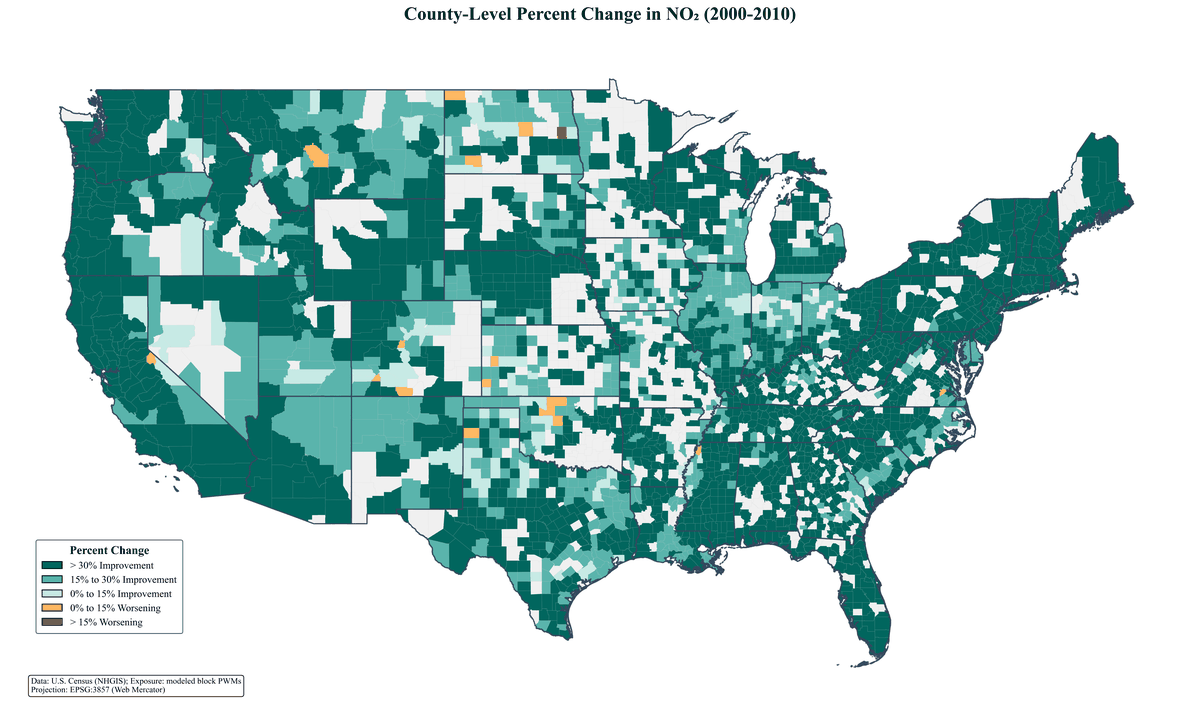


--- Fine Particulate Matter (PM2.5) Percent Change (2000-2010) ---


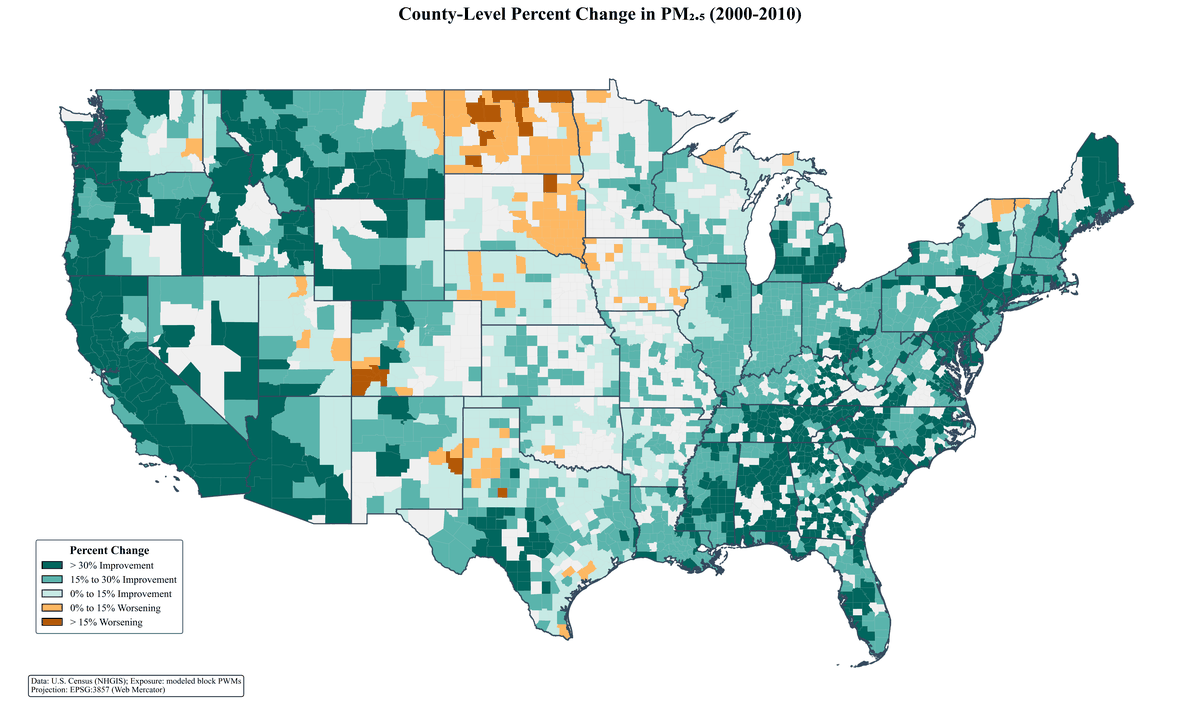

In [ ]:
# @title Figure 3: Spatiotemporal Change in Air Quality (2000-2010)
# Displaying the Percent Change Choropleth Maps

import os
from IPython.display import Image, display

if 'ASSETS_DIR' not in locals():
    ASSETS_DIR = resolve_assets_dir()

maps = [
    'county_percent_change_NO2.png',
    'county_percent_change_PM25.png'
]

for map_file in maps:
    filepath = ASSETS_DIR / map_file
    if filepath.exists():
        label = "Nitrogen Dioxide (NO2)" if "NO2" in map_file else "Fine Particulate Matter (PM2.5)"
        print(f"\n--- {label} Percent Change (2000-2010) ---")
        show_figure(filepath, width=900)
    else:
        print(f"Asset not found: {map_file}")

<a id="43-intersectional-analysis-historical-redlining" name="43-intersectional-analysis-historical-redlining"></a>

### **4.3 Intersectional Analysis: Historical Redlining**
We identified a monotonic relationship between historical HOLC security grades and contemporary pollution exposure. In 2010, the PWM $NO_2$ concentration in Grade D ("Hazardous") areas was 16.8 ppb, compared to 10.7 ppb in Grade A ("Best") areas.

Critically, racial disparities persist *within* historical grades. As shown in the intersectional heatmaps below, Non-Hispanic Black and Hispanic populations experience higher exposures than White populations even when residing in neighborhoods with the same historical HOLC classification (Lane et al., 2022).


--- NO2 Intersectional Exposure (2000) ---


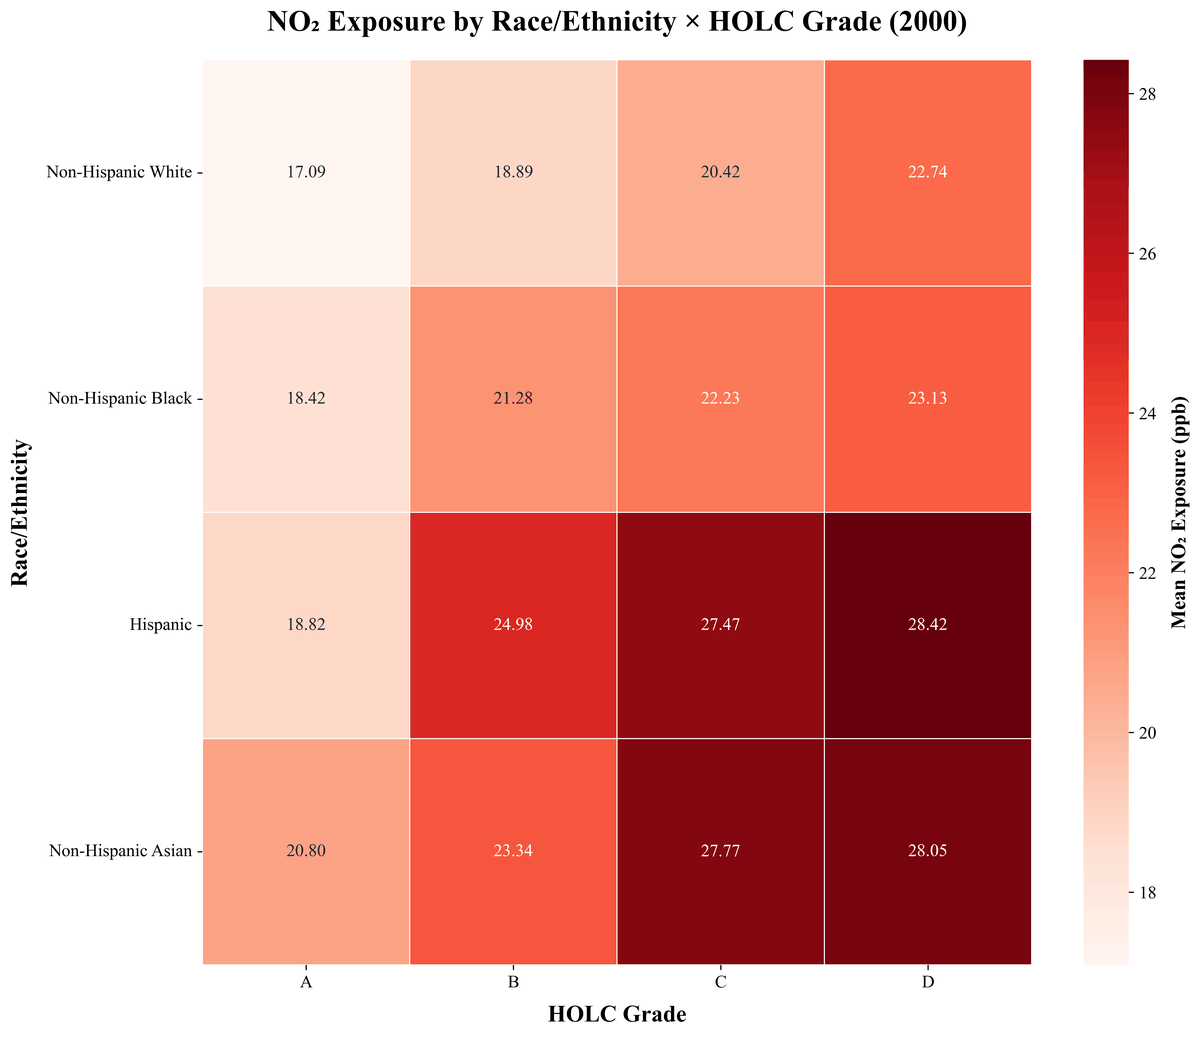


--- NO2 Intersectional Exposure (2010) ---


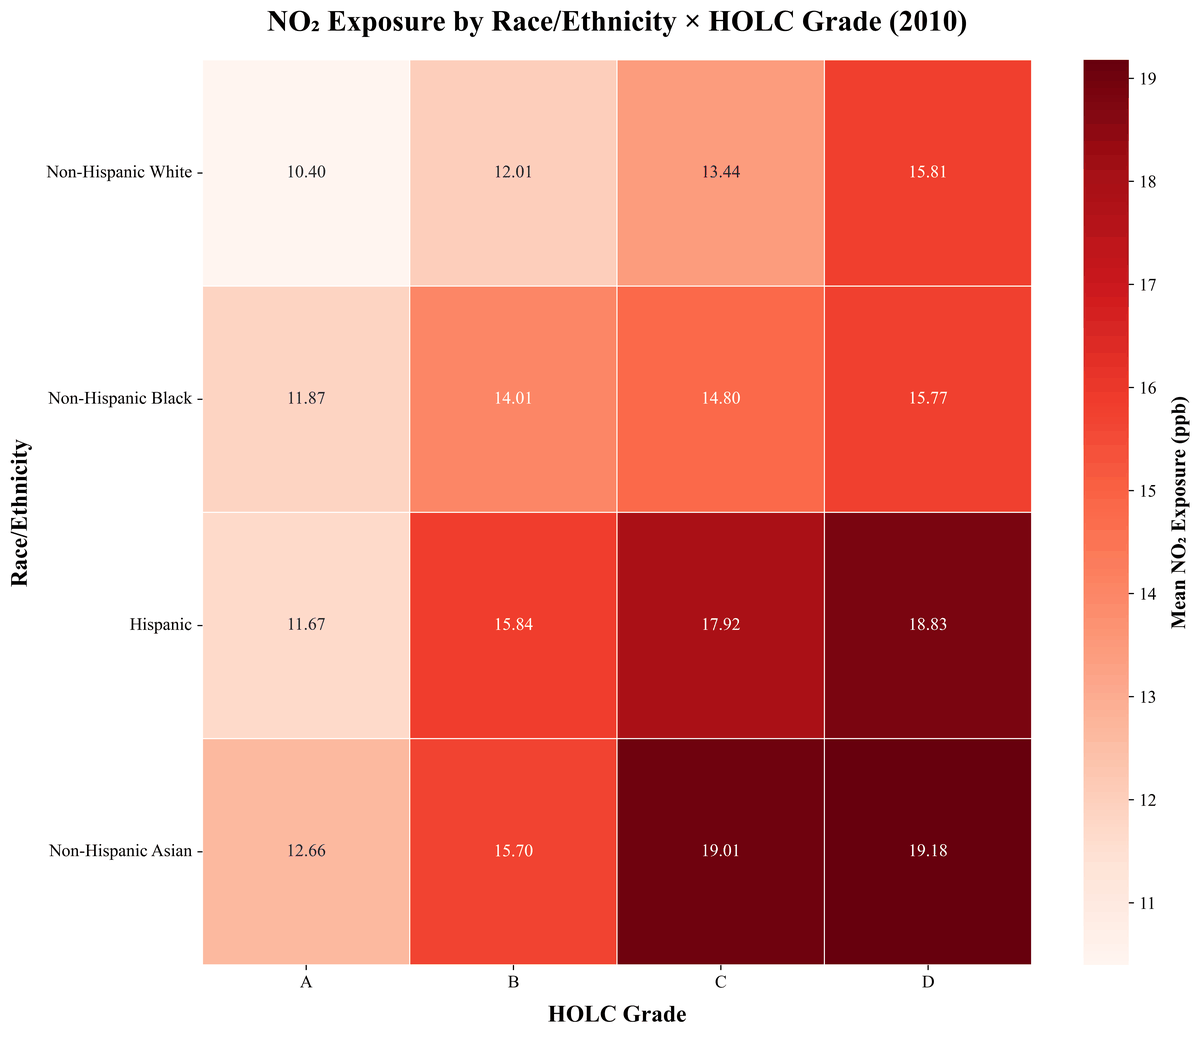


--- PM2.5 Intersectional Exposure (2000) ---


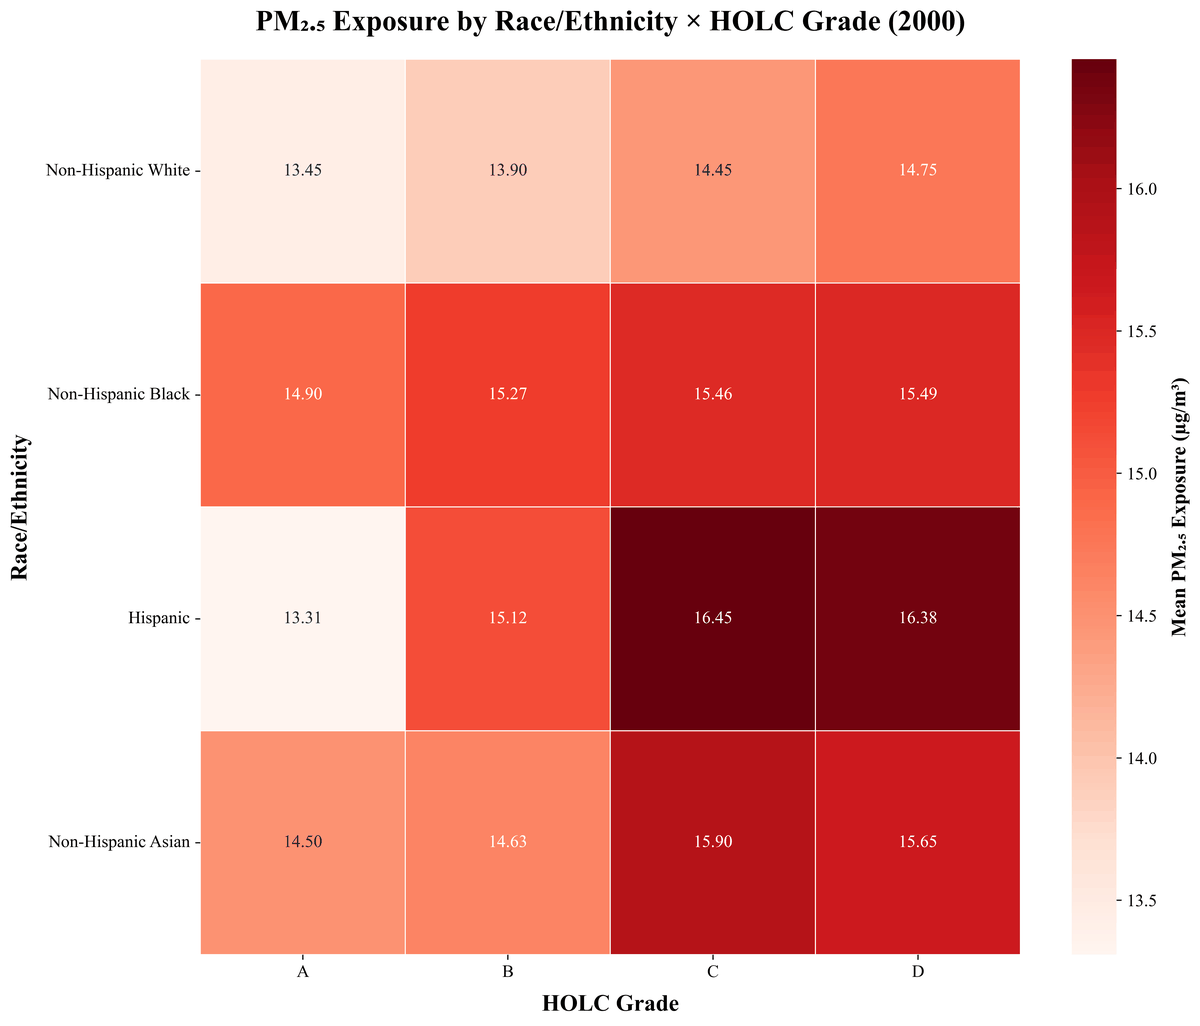


--- PM2.5 Intersectional Exposure (2010) ---


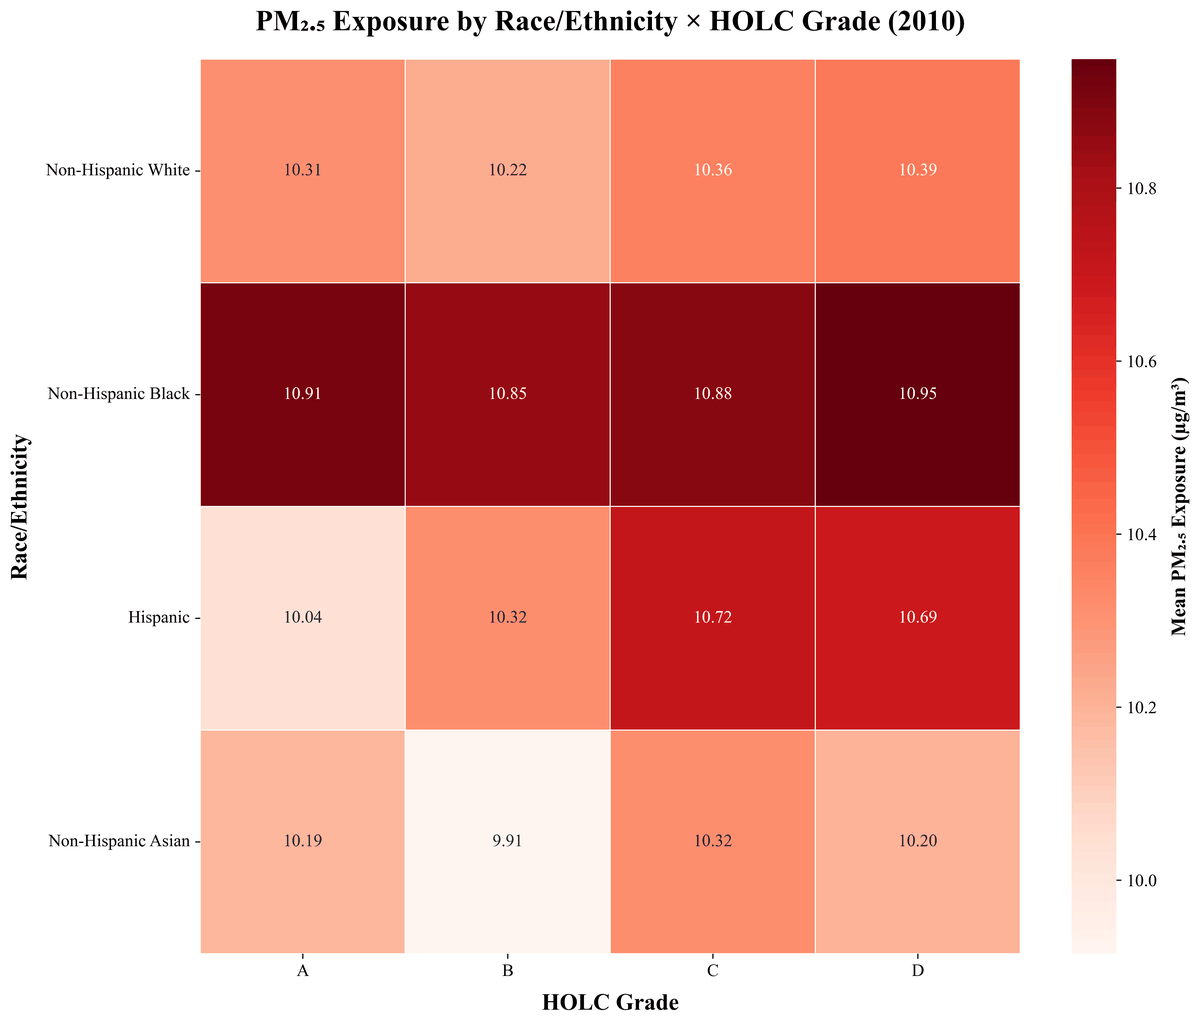

In [ ]:
# @title Figure 4: Intersectional Exposure Heatmaps (Race x HOLC Grade)
from IPython.display import Image, display

if 'ASSETS_DIR' not in locals():
    ASSETS_DIR = resolve_assets_dir()

heatmap_files = [
    'intersectional_heatmap_NO2_2000.png',
    'intersectional_heatmap_NO2_2010.png',
    'intersectional_heatmap_PM25_2000.png',
    'intersectional_heatmap_PM25_2010.png'
]

for hm_file in heatmap_files:
    filepath = ASSETS_DIR / hm_file
    if filepath.exists():
        # dynamic label and year detection
        label = "NO2" if "NO2" in hm_file else "PM2.5"
        year = "2000" if "2000" in hm_file else "2010"

        print(f"\n--- {label} Intersectional Exposure ({year}) ---")
        show_figure(filepath, width=800)
    else:
        print(f"Asset not found: {hm_file}")

<a id="5-discussion" name="5-discussion"></a>

## **5. Discussion**
The persistence of relative disparities despite aggregate air quality improvements suggests that non-targeted regulatory approaches are insufficient to close the environmental equity gap (Clark et al., 2017; Liu et al., 2021). The association between 1930s redlining grades and 2010 pollution levels is consistent with the spatial structure of historical discrimination continuing to shape modern environmental health burdens (Lane et al., 2022; Liu & Marshall, 2023). The design is observational, so this is an association that persists after stratification, not an identified causal effect.

<a id="51-limitations" name="51-limitations"></a>

### **5.1 Limitations**
* **Ecological Fallacy:** Exposure is assigned at the census block level, which may not represent individual personal exposure.
* **Static Boundaries:** The analysis uses static 1930s HOLC boundaries and does not explicitly account for boundary changes or gentrification dynamics in the intervening decades.
* **Effective Sample Size:** Approximately 3.08 million census blocks are not 3.08 million independent observations. Strong spatial autocorrelation places the effective sample size far below $n$, so interval estimates computed under an independence assumption are too narrow. Cluster-robust or spatially-corrected standard errors are required before these intervals are interpreted.
* **Spatial Scale Is Not Emission Sector:** The underlying concentration fields decompose by distance scale (long-range, mid-range, neighborhood, near-source), not by emission source category. Reading a near-source contribution as traffic, or a long-range contribution as wildfire smoke or dust, is a proxy interpretation pending validation against a source-specific product.
* **Modeled Exposure Surfaces:** Concentrations are model estimates from empirical geographic regression (Kim et al., 2020; Wang et al., 2020), not monitor observations, and carry their own spatially structured prediction error, which is not propagated into the disparity statistics reported here.

<a id="6-conclusion" name="6-conclusion"></a>

## **6. Conclusion**
This study quantifies a durable environmental injustice. The "sacrifice zones" created by historical policy decisions remain the loci of the highest pollution burdens today. Achieving environmental equity requires policy interventions that specifically target these intersectional hotspots of race, historical disadvantage, and pollution.

<a id="7-future-research-directions" name="7-future-research-directions"></a>

## **7. Future Research Directions**
Future work should integrate longitudinal health outcome data to quantify the specific morbidity and mortality burdens attributable to these exposure disparities. Additionally, applying machine learning to model the trajectory of "gentrifying" redlined areas could predict future displacement and exposure shifts.

<a id="8-interactive-digital-assets" name="8-interactive-digital-assets"></a>

## **8. Interactive Digital Assets**
To facilitate deeper exploration of these spatial patterns, we have developed interactive ArcGIS StoryMaps. These allow reviewers and the public to zoom into specific neighborhoods and explore the data at a granular level.

* **PM2.5 Analysis:** [Explore the PM2.5 StoryMap](https://arcg.is/Peaff)
* **NO2 Analysis:** [Explore the NO2 StoryMap](https://arcg.is/rPzfS0)

<a id="9-acknowledgments-and-data-sources" name="9-acknowledgments-and-data-sources"></a>

## **9. Acknowledgments and Data Sources**
* **Census Data:** IPUMS National Historical Geographic Information System (NHGIS) (Manson et al., 2024).
* **Pollution Data:** Center for Air, Climate, and Energy Solutions (CACES) (Kim et al., 2020; Wang, 2022).
* **Redlining Data:** *Mapping Inequality*, University of Richmond (Nelson et al., 2023).

<a id="10-references" name="10-references"></a>

## **10. References**

Clark, L. P., Millet, D. B., & Marshall, J. D. (2017). Changes in transportation-related air pollution exposures by race-ethnicity and socioeconomic status: Outdoor nitrogen dioxide in the United States in 2000 and 2010. *Environmental Health Perspectives*, *125*(9), 097012. https://doi.org/10.1289/EHP959

Kim, S.-Y., Bechle, M., Hankey, S., Sheppard, L., Szpiro, A. A., & Marshall, J. D. (2020). Concentrations of criteria pollutants in the contiguous U.S., 1979-2015: Role of prediction model parsimony in integrated empirical geographic regression. *PLOS ONE*, *15*(2), e0228535. https://doi.org/10.1371/journal.pone.0228535

Lane, H. M., Morello-Frosch, R., Marshall, J. D., & Apte, J. S. (2022). Historical redlining is associated with present-day air pollution disparities in U.S. cities. *Environmental Science & Technology Letters*, *9*(4), 345–350. https://doi.org/10.1021/acs.estlett.1c01012

Liu, J., Clark, L. P., Bechle, M. J., Hajat, A., Kim, S.-Y., Robinson, A. L., Sheppard, L., Szpiro, A. A., & Marshall, J. D. (2021). Disparities in air pollution exposure in the United States by race/ethnicity and income, 1990–2010. *Environmental Health Perspectives*, *129*(12), 127005. https://doi.org/10.1289/EHP8584

Liu, J., & Marshall, J. D. (2023). Spatial decomposition of air pollution concentrations highlights historical causes for current exposure disparities in the United States. *Environmental Science & Technology Letters*, *10*(3), 280–286. https://doi.org/10.1021/acs.estlett.2c00826

Manson, S., Schroeder, J., Van Riper, D., Knowles, K., Kugler, T., Roberts, F., & Ruggles, S. (2024). *IPUMS National Historical Geographic Information System: Version 19.0* [Dataset]. IPUMS. https://doi.org/10.18128/D050.V19.0

Marshall, J. D. (2008). Environmental inequality: Air pollution exposures in California’s South Coast Air Basin. *Atmospheric Environment*, *42*, 5499–5503. https://doi.org/10.1016/j.atmosenv.2008.02.005

Nelson, R. K., Winling, L., Marciano, R., & Connolly, N. (2023). *Mapping inequality: Redlining in New Deal America*. Digital Scholarship Lab. https://dsl.richmond.edu/panorama/redlining

Wang, Y. (2022). *Data for: Spatial decomposition of NO2 and PM2.5 air pollution in the United States* (Version 3) [Dataset]. Mendeley Data. https://doi.org/10.17632/bz8pdbcvf2.3

Wang, Y., Bechle, M. J., Kim, S.-Y., Adams, P. J., Pandis, S. N., Pope, C. A., III, Robinson, A. L., Sheppard, L., Szpiro, A. A., & Marshall, J. D. (2020). Spatial decomposition analysis of NO2 and PM2.5 air pollution in the United States. *Atmospheric Environment*, *241*, 117470. https://doi.org/10.1016/j.atmosenv.2020.117470

Wang, Y., Apte, J. S., Hill, J. D., Ivey, C. E., Patterson, R. F., Robinson, A. L., Tessum, C. W., & Marshall, J. D. (2022b). Location-specific strategies for eliminating US national racial-ethnic PM2.5 exposure inequality. *Proceedings of the National Academy of Sciences*, *119*(44), e2205548119. https://doi.org/10.1073/pnas.2205548119